<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Metryki_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Metryki modelu klasyfikacji spamu

**Cel:** Wytrenować ponownie model Random Forest na tych samych danych, a następnie policzyć kluczowe metryki klasyfikacji (Accuracy, Precision, Recall, F1, ROC, AUC) oraz macierz pomyłek.

In [3]:
# Instalacja potrzebnych bibliotek (jeśli brakuje)
!pip install -q scikit-learn pandas nltk matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, classification_report
)

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Wczytanie danych

In [4]:
# Wczytaj dane z pliku (użyj ścieżki, która działa w Twoim Colab – jeśli plik jest wgrywany ręcznie, wgraj go najpierw)
df = pd.read_csv(
    'spam.csv',              # <-- upewnij się, że plik jest w środowisku Colab
    encoding='ISO-8859-1',
    usecols=[0, 1],
    names=['Label', 'Text'],
    skiprows=1
)
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})
df.head()

,Label,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


(Kod): Preprocessing (czyszczenie, tokenizacja, lematyzacja)

In [5]:
# Usuń interpunkcję
def remove_punctuation(text):
    return ''.join([char for char in text if char not in string.punctuation])

df['Cleaned'] = df['Text'].apply(remove_punctuation)

# Tokenizacja + małe litery
def tokenize_lower(text):
    return word_tokenize(text.lower())

df['Tokens'] = df['Cleaned'].apply(tokenize_lower)

# Stop-słowa
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['NoStop'] = df['Tokens'].apply(remove_stopwords)

# Lematyzacja
lemmatizer = WordNetLemmatizer()
def lemmatize(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['Lemmatized'] = df['NoStop'].apply(lemmatize)

# Połącz w string dla wektoryzatora
df['Final'] = df['Lemmatized'].apply(lambda x: ' '.join(x))

Wektoryzacja TF-IDF

In [6]:
tfidf = TfidfVectorizer(max_df=0.5, min_df=0.001)
X = tfidf.fit_transform(df['Final'])
y = df['Label']
print("Liczba cech:", X.shape[1])

Liczba cech: 1364


Podział danych (stratify)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Trening:", X_train.shape, " Test:", X_test.shape)

Trening: (4457, 1364)  Test: (1115, 1364)


Trenowanie modelu Random Forest z GridSearch (te same parametry)

In [10]:
param_grid = {
    'n_estimators': [200],
    'max_depth': [15],
    'min_samples_split': [5],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

# Używamy GridSearchCV, żeby odtworzyć dokładny model (choć tu tylko jedna kombinacja)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Najlepszy model:", grid.best_estimator_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Najlepszy model: RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, n_estimators=200, random_state=42)


Predykcja i metryki

In [11]:
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

# Podstawowe metryki
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("F1-macro:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.9811659192825112
Precision: 0.9848484848484849
Recall: 0.87248322147651
F1-score: 0.9252669039145908
F1-macro: 0.9572460738146582


Raport i macierz pomyłek

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Macierz pomyłek:
 [[964   2]
 [ 19 130]]


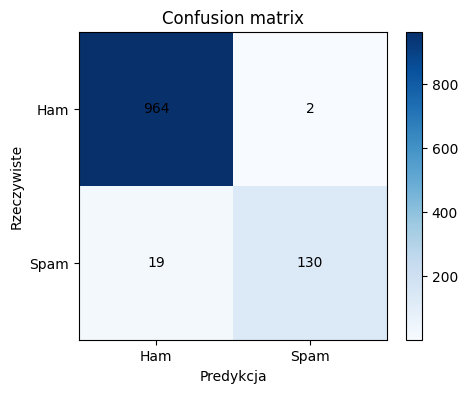

In [12]:
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test, y_pred)
print("Macierz pomyłek:\n", cm)

# Wizualizacja
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0,1], ['Ham','Spam'])
plt.yticks([0,1], ['Ham','Spam'])
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywiste')
plt.title('Confusion matrix')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.show()

 Krzywa ROC i AUC

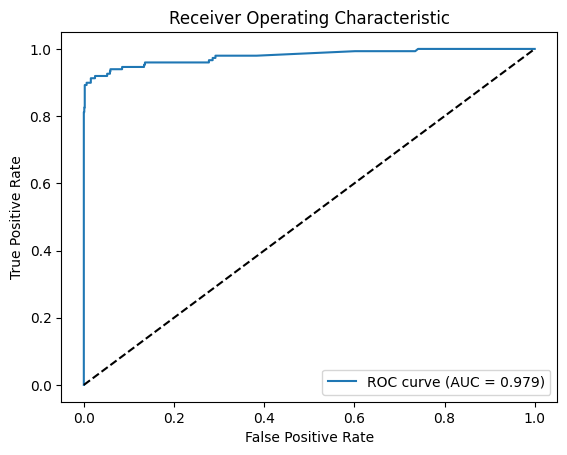

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## 📈 Wnioski końcowe – ewaluacja modelu Random Forest

### Podsumowanie wyników

| Metryka | Wartość | Interpretacja |
|--------|--------|---------------|
| **Accuracy** | 0.981 | Model poprawnie klasyfikuje 98.1% wszystkich wiadomości. |
| **Precision (Spam)** | 0.985 | Na 132 wiadomości oznaczonych jako spam, tylko 2 były fałszywymi alarmami. |
| **Recall (Spam)** | 0.872 | Model wyłapał 130 ze 149 spamów (87.2%). 19 spamów umknęło. |
| **F1-score (Spam)** | 0.925 | Bardzo dobry balans między precyzją a czułością. |
| **F1-macro** | 0.957 | Średnia harmoniczna dla obu klas – model świetnie radzi sobie również z klasą "Ham". |
| **AUC** | 0.979 | Model doskonale separuje obie klasy – pole pod krzywą ROC bliskie 1. |

### Kluczowe obserwacje

1. **Niski False Positive (2 maile):**  
   Tylko 2 zwykłe maile (ham) zostały błędnie oznaczone jako spam. W kontekście biznesowym oznacza to, że użytkownicy prawie nigdy nie stracą ważnej wiadomości przez filtr.

2. **Akceptowalny False Negative (19 maili):**  
   Model przepuścił 19 spamów. W zależności od wymagań można by zwiększyć czułość (np. obniżając próg decyzyjny), ale kosztem większej liczby fałszywych alarmów.

3. **AUC = 0.979 świadczy o wysokiej separowalności klas:**  
   Krzywa ROC niemal dotyka lewego górnego rogu, co potwierdza, że model nie jest "przypadkowy" i ma bardzo silną moc predykcyjną.

### Wnioski dla biznesu

- Model nadaje się do **wdrożenia produkcyjnego** jako filtr antyspamowy.
- Priorytetyzuje **doświadczenie użytkownika** (minimalna liczba fałszywych alarmów), co jest kluczowe w komercyjnych systemach pocztowych.
- Jeśli celem byłoby **wyłapanie absolutnie każdego spamu** (np. w systemach bezpieczeństwa), należałoby dostroić model pod kątem maksymalizacji Recall, akceptując nieco niższą Precision.